In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import math
import os
import joblib

# Forecasting Prototype

We build an initial forecasting model on a single store-family series to demonstrate feasibility before scaling to the full dataset. A Seasonal Naive baseline is compared against XGBoost over a 15-day validation window, matching the forecast horizon defined in the proposal.

In [5]:
df = pd.read_csv('../data/processed/clean_sample.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')

print("Rows:", len(df))
print("Columns:", df.columns.tolist())
print("Date range:", df.index.min().date(), "to", df.index.max().date())
df.head()

Rows: 1684
Columns: ['id', 'store_nbr', 'family', 'sales', 'onpromotion', 'is_open']
Date range: 2013-01-01 to 2017-08-15


,id,store_nbr,family,sales,onpromotion,is_open
date,,,,,,
2013-01-01,3,1,BEVERAGES,0.0,0,False
2013-01-02,1785,1,BEVERAGES,1091.0,0,True
2013-01-03,3567,1,BEVERAGES,919.0,0,True
2013-01-04,5349,1,BEVERAGES,953.0,0,True
2013-01-05,7131,1,BEVERAGES,1160.0,0,True


### 1. Feature Engineering

We build calendar features, lag features, and rolling statistics. Lags and rolling means are shifted by one day so that no future information leaks into the training data.

In [6]:
df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['dayofweek'] = df.index.dayofweek
df['weekofyear'] = df.index.isocalendar().week.astype(int)

df['lag_1'] = df['sales'].shift(1)
df['lag_7'] = df['sales'].shift(7)
df['lag_14'] = df['sales'].shift(14)
df['rolling_mean_7'] = df['sales'].shift(1).rolling(7).mean()
df['rolling_mean_14'] = df['sales'].shift(1).rolling(14).mean()

df['is_open'] = df['is_open'].astype(int)

print("Features created. Shape:", df.shape)
df[['sales', 'lag_1', 'lag_7', 'rolling_mean_7', 'is_open']].tail()

Features created. Shape: (1684, 16)


,sales,lag_1,lag_7,rolling_mean_7,is_open
date,,,,,
2017-08-11,1006.0,2377.0,2479.0,2104.571429,1
2017-08-12,1659.0,1006.0,2093.0,1894.142857,1
2017-08-13,803.0,1659.0,968.0,1832.142857,1
2017-08-14,2201.0,803.0,2086.0,1808.571429,1
2017-08-15,1942.0,2201.0,2418.0,1825.000000,1


### 2. Train-Validation Split

We split the data chronologically, holding out the final 15 days for validation. This matches the forecast horizon defined in the proposal and preserves the temporal order, which a random split would destroy.

In [8]:
horizon = 15
df_model = df.dropna()

train = df_model.iloc[:-horizon]
validation = df_model.iloc[-horizon:].copy()

feature_cols = ['year', 'month', 'day', 'dayofweek', 'weekofyear',
                'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_14',
                'is_open', 'onpromotion']

print(f"Train: {len(train)} rows ({train.index.min().date()} to {train.index.max().date()})")
print(f"Validation: {len(validation)} rows ({validation.index.min().date()} to {validation.index.max().date()})")

Train: 1655 rows (2013-01-15 to 2017-07-31)
Validation: 15 rows (2017-08-01 to 2017-08-15)


### 3. Baseline Model — Seasonal Naive

The seasonal naive method predicts each day using the value from the same weekday in the previous week. It requires no training and serves as the benchmark that any model must beat to justify its complexity.

In [9]:
seasonal_period = 7
last_week = train['sales'].iloc[-seasonal_period:].values

validation['baseline_pred'] = np.tile(
    last_week, math.ceil(len(validation) / seasonal_period)
)[:len(validation)]

print(validation[['sales', 'baseline_pred']].round(0))

             sales  baseline_pred
date                             
2017-08-01  2627.0         2438.0
2017-08-02  2645.0         2242.0
2017-08-03  2037.0         2002.0
2017-08-04  2479.0         2358.0
2017-08-05  2093.0         2161.0
2017-08-06   968.0         1212.0
2017-08-07  2086.0         2414.0
2017-08-08  2418.0         2438.0
2017-08-09  2311.0         2242.0
2017-08-10  2377.0         2002.0
2017-08-11  1006.0         2358.0
2017-08-12  1659.0         2161.0
2017-08-13   803.0         1212.0
2017-08-14  2201.0         2414.0
2017-08-15  1942.0         2438.0


### 4. XGBoost Model

We train a gradient boosting model on the engineered features and compare its performance against the baseline over the same validation window.

In [10]:
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(train[feature_cols], train['sales'])
validation['xgb_pred'] = xgb_model.predict(validation[feature_cols])

print(validation[['sales', 'baseline_pred', 'xgb_pred']].round(0))

             sales  baseline_pred  xgb_pred
date                                       
2017-08-01  2627.0         2438.0    2523.0
2017-08-02  2645.0         2242.0    2503.0
2017-08-03  2037.0         2002.0    2160.0
2017-08-04  2479.0         2358.0    2366.0
2017-08-05  2093.0         2161.0    2362.0
2017-08-06   968.0         1212.0    1001.0
2017-08-07  2086.0         2414.0    2115.0
2017-08-08  2418.0         2438.0    2318.0
2017-08-09  2311.0         2242.0    2392.0
2017-08-10  2377.0         2002.0    2116.0
2017-08-11  1006.0         2358.0    2286.0
2017-08-12  1659.0         2161.0    2037.0
2017-08-13   803.0         1212.0     963.0
2017-08-14  2201.0         2414.0    2281.0
2017-08-15  1942.0         2438.0    2363.0


### 5. Evaluation

We evaluate both models using MAE, RMSE, and WMAPE. WMAPE is included because it expresses error as a percentage of total sales, making it interpretable across series of different scales.

In [11]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
    print(f"{name:28s} MAE: {mae:8.2f} | RMSE: {rmse:8.2f} | WMAPE: {wmape:6.2f}%")

evaluate(validation['sales'], validation['baseline_pred'], "Seasonal Naive (Baseline)")
evaluate(validation['sales'], validation['xgb_pred'], "XGBoost")

Seasonal Naive (Baseline)    MAE:   321.60 | RMSE:   452.41 | WMAPE:  16.27%
XGBoost                      MAE:   238.36 | RMSE:   383.83 | WMAPE:  12.06%


### 6. Forward Forecast

We generate a 15-day forecast beyond the end of the dataset. Since lag features depend on recent values that do not yet exist, predictions are made recursively: each forecast is appended to the history and used as input for the next day.

In [12]:
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=horizon,
    freq='D'
)

last_week_full = df['sales'].iloc[-seasonal_period:].values
baseline_future = np.tile(
    last_week_full, math.ceil(horizon / seasonal_period)
)[:horizon]

history = df['sales'].copy()
xgb_future_preds = []

for date in future_dates:
    row = {
        'year': date.year,
        'month': date.month,
        'day': date.day,
        'dayofweek': date.dayofweek,
        'weekofyear': date.isocalendar()[1],
        'lag_1': history.iloc[-1],
        'lag_7': history.iloc[-7],
        'lag_14': history.iloc[-14],
        'rolling_mean_7': history.iloc[-7:].mean(),
        'rolling_mean_14': history.iloc[-14:].mean(),
        'is_open': 1,
        'onpromotion': 0
    }
    X_future = pd.DataFrame([row])[feature_cols]
    pred = xgb_model.predict(X_future)[0]
    xgb_future_preds.append(pred)
    history.loc[date] = pred

future_forecast = pd.DataFrame({
    'date': future_dates,
    'baseline_pred': baseline_future,
    'xgb_pred': xgb_future_preds
}).set_index('date')

print(future_forecast.round(0))

            baseline_pred  xgb_pred
date                               
2017-08-16         2311.0    2382.0
2017-08-17         2377.0    2076.0
2017-08-18         1006.0    2301.0
2017-08-19         1659.0    2103.0
2017-08-20          803.0     969.0
2017-08-21         2201.0    2059.0
2017-08-22         1942.0    2037.0
2017-08-23         2311.0    2222.0
2017-08-24         2377.0    1994.0
2017-08-25         1006.0    2094.0
2017-08-26         1659.0    2091.0
2017-08-27          803.0     958.0
2017-08-28         2201.0    2027.0
2017-08-29         1942.0    2081.0
2017-08-30         2311.0    2202.0


### 7. Visualisation

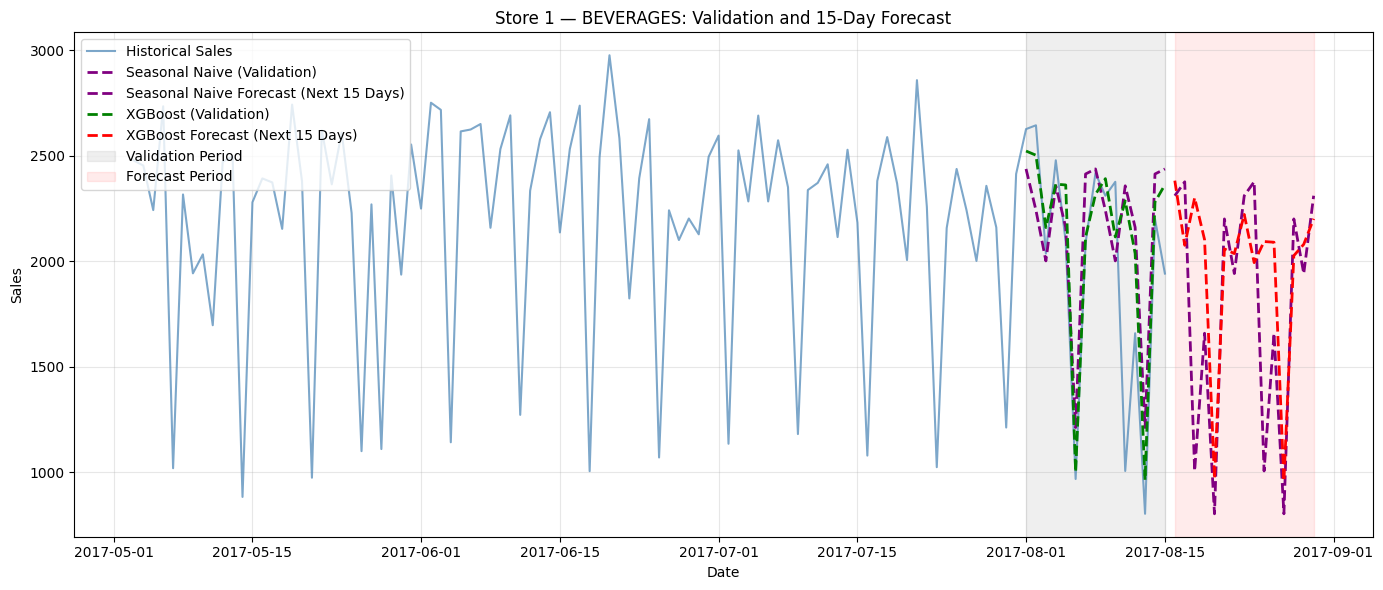

In [19]:
zoom_days = 90
plot_start = validation.index[0] - pd.Timedelta(days=zoom_days)

plt.figure(figsize=(14, 6))

plt.plot(df.loc[plot_start:].index, df.loc[plot_start:, 'sales'],
         label='Historical Sales', color='steelblue', alpha=0.7)

plt.plot(validation.index, validation['baseline_pred'],
         label='Seasonal Naive (Validation)', color='purple', linestyle='--', linewidth=2)

plt.plot(future_forecast.index, future_forecast['baseline_pred'],
         label='Seasonal Naive Forecast (Next 15 Days)', color='purple', linestyle='--', linewidth=2)

plt.plot(validation.index, validation['xgb_pred'],
         label='XGBoost (Validation)', color='green', linestyle='--', linewidth=2)

plt.plot(future_forecast.index, future_forecast['xgb_pred'],
         label='XGBoost Forecast (Next 15 Days)', color='red', linestyle='--', linewidth=2)

plt.axvspan(validation.index[0], validation.index[-1],
            color='gray', alpha=0.12, label='Validation Period')
plt.axvspan(future_forecast.index[0], future_forecast.index[-1],
            color='red', alpha=0.08, label='Forecast Period')

plt.title('Store 1 — BEVERAGES: Validation and 15-Day Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 8. Saving Model and Forecasts

We save the trained model and forecast outputs so they can be loaded directly by the Streamlit application without retraining.

In [16]:
os.makedirs('../models', exist_ok=True)
os.makedirs('../outputs/forecasts', exist_ok=True)

joblib.dump(xgb_model, '../models/xgb_store1_beverages.pkl')

validation[['sales', 'baseline_pred', 'xgb_pred']].to_csv(
    '../outputs/forecasts/validation_results.csv'
)
future_forecast.to_csv('../outputs/forecasts/forward_forecast_15d.csv')

print("Model saved to: models/xgb_store1_beverages.pkl")
print("Forecasts saved to: outputs/forecasts/")

Model saved to: models/xgb_store1_beverages.pkl
Forecasts saved to: outputs/forecasts/


### Insight

We trained an initial forecasting prototype on a single store-family series (Store 1, BEVERAGES) to demonstrate feasibility before scaling to the full dataset.

Over a 15-day validation window, XGBoost outperformed the Seasonal Naive baseline across all three metrics: MAE improved from 321.60 to 238.36 (−26%), RMSE from 452.41 to 383.83 (−15%), and WMAPE from 16.27% to 12.06%.

The performance gap is concentrated in weekly troughs. The seasonal naive method repeats the previous week's values regardless of context, which fails when a low-sales day does not align with the same weekday a week earlier. XGBoost, having access to store opening status and promotion counts alongside lag features, tracked these dips closely — predicting 1,001 against an actual 968 on 6 August, where